# Data preprocessing

In [1]:
import os 
import pandas as pd
def addToDataFrame(df, path, label):
    for f in os.listdir(path):
        if f.endswith('.png'):
            df = pd.concat([df, pd.DataFrame([{'path': os.path.join(path, f), 'label': label}])], ignore_index=True)
            
    return df
df = pd.DataFrame(columns=['path', 'label'])
df = addToDataFrame(df, 'Dataset_DICOM/Bleeding', '1') 
df = addToDataFrame(df, 'Dataset_DICOM/Ischemia', '2')
df = addToDataFrame(df, 'Dataset_DICOM/Normal', '0')

In [2]:
df.head(5)

,path,label
0,Dataset_DICOM/Bleeding\10002.png,1
1,Dataset_DICOM/Bleeding\10033.png,1
2,Dataset_DICOM/Bleeding\10036.png,1
3,Dataset_DICOM/Bleeding\10039.png,1
4,Dataset_DICOM/Bleeding\10045.png,1


In [3]:
df.describe()

,path,label
count,6648,6648
unique,6648,3
top,Dataset_DICOM/Bleeding\10002.png,0
freq,1,4427


In [4]:
from sklearn.model_selection import train_test_split
train, validation = train_test_split(df, test_size=0.2, random_state=42)
print(f'Training samples: {len(train)}')
print(f'Validation samples: {len(validation)}')

Training samples: 5318
Validation samples: 1330


https://discuss.pytorch.org/t/feature-extraction-using-pretrained-alexnet/145026

In [5]:
from torchvision import models
import torch.nn as nn
AlexNet = models.alexnet(pretrained=True)
#Necessary to remove the last layers since we aim for feature extraction
AlexNet.classifier=nn.Sequential(*list(AlexNet.classifier.children())[:-4]) 

c:\Users\Patrik P\Downloads\AlexNet with SVM\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Patrik P\Downloads\AlexNet with SVM\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


model.eval()- essential for PyThorch, used during validation and testing. For AlexNet we don't want to train the model anymore but to make the model evaluate our pictures and return the feature extraction values. <br><br>
The AlexNet model expects 224x224 images.<br><br>
Achieved higher accuracy and scores through the normalization values which appear here:https://pytorch.org/hub/pytorch_vision_alexnet/


In [6]:
import numpy as np
from PIL import Image
from torchvision import transforms
def extract_features(dataframe, model):
    preprocess=transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    features_list = []
    labels_list = []
    model.eval()
    for idx, row in dataframe.iterrows():
        img=Image.open(row['path']).convert('RGB')
        img_array= preprocess(img)
        img_array = img_array.unsqueeze(0)
        features= model(img_array)
        features= features.reshape(features.shape[0], -1)
        #Convert features to numpy array
        features_np=features.detach().numpy()
        features_list.append(features_np)
    
        labels_list.append(int(row['label']))
    
    X=np.vstack(features_list)
    y=np.array(labels_list)
    return X, y

In [7]:

X_train, y_train = extract_features(train, AlexNet)
X_val, y_val = extract_features(validation, AlexNet)

# SVM

class_weight='balanced' automatically calculates the weights of the classes.

In [9]:
import optuna
from sklearn.metrics import f1_score
from sklearn.svm import SVC
def objective(trial):
    c=trial.suggest_float('C',1,100)
    kernel=trial.suggest_categorical('kernel', ['linear', 'rbf'])
    degree=trial.suggest_int('degree', 2, 5)

    model=SVC(C=c, kernel=kernel, degree=degree,class_weight='balanced',decision_function_shape='ovo')
    model.fit(X_train, y_train)
    y_pred=model.predict(X_val)
    return f1_score(y_val, y_pred, average='weighted')
study=optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10,show_progress_bar=True)
study.best_params

[I 2026-04-24 17:11:58,816] A new study created in memory with name: no-name-ab1bd684-96b1-40ae-974b-0cb8cbad0d6c
Best trial: 0. Best value: 0.883983:  10%|█         | 1/10 [00:27<04:08, 27.65s/it]

[I 2026-04-24 17:12:26,464] Trial 0 finished with value: 0.8839826477610767 and parameters: {'C': 84.11789251228893, 'kernel': 'linear', 'degree': 4}. Best is trial 0 with value: 0.8839826477610767.


Best trial: 1. Best value: 0.937568:  20%|██        | 2/10 [01:07<04:36, 34.56s/it]

[I 2026-04-24 17:13:05,866] Trial 1 finished with value: 0.9375683023117596 and parameters: {'C': 59.60786512835825, 'kernel': 'rbf', 'degree': 3}. Best is trial 1 with value: 0.9375683023117596.


Best trial: 1. Best value: 0.937568:  30%|███       | 3/10 [01:46<04:16, 36.70s/it]

[I 2026-04-24 17:13:45,106] Trial 2 finished with value: 0.9375683023117596 and parameters: {'C': 80.5735151066462, 'kernel': 'rbf', 'degree': 4}. Best is trial 1 with value: 0.9375683023117596.


Best trial: 1. Best value: 0.937568:  40%|████      | 4/10 [02:25<03:46, 37.70s/it]

[I 2026-04-24 17:14:24,345] Trial 3 finished with value: 0.9375683023117596 and parameters: {'C': 59.70281741184959, 'kernel': 'rbf', 'degree': 3}. Best is trial 1 with value: 0.9375683023117596.


Best trial: 1. Best value: 0.937568:  50%|█████     | 5/10 [02:54<02:52, 34.45s/it]

[I 2026-04-24 17:14:53,044] Trial 4 finished with value: 0.8839826477610767 and parameters: {'C': 25.967078088865346, 'kernel': 'linear', 'degree': 4}. Best is trial 1 with value: 0.9375683023117596.


Best trial: 1. Best value: 0.937568:  60%|██████    | 6/10 [03:34<02:25, 36.28s/it]

[I 2026-04-24 17:15:32,877] Trial 5 finished with value: 0.9354720250670688 and parameters: {'C': 19.597896584128172, 'kernel': 'rbf', 'degree': 5}. Best is trial 1 with value: 0.9375683023117596.


Best trial: 1. Best value: 0.937568:  70%|███████   | 7/10 [04:17<01:55, 38.54s/it]

[I 2026-04-24 17:16:16,075] Trial 6 finished with value: 0.9367781667413752 and parameters: {'C': 34.7739879796308, 'kernel': 'rbf', 'degree': 3}. Best is trial 1 with value: 0.9375683023117596.


Best trial: 1. Best value: 0.937568:  80%|████████  | 8/10 [04:45<01:10, 35.39s/it]

[I 2026-04-24 17:16:44,702] Trial 7 finished with value: 0.8839826477610767 and parameters: {'C': 37.45273305321561, 'kernel': 'linear', 'degree': 4}. Best is trial 1 with value: 0.9375683023117596.


Best trial: 1. Best value: 0.937568:  90%|█████████ | 9/10 [05:15<00:33, 33.54s/it]

[I 2026-04-24 17:17:14,176] Trial 8 finished with value: 0.8839826477610767 and parameters: {'C': 60.924757812661646, 'kernel': 'linear', 'degree': 4}. Best is trial 1 with value: 0.9375683023117596.


Best trial: 1. Best value: 0.937568: 100%|██████████| 10/10 [05:45<00:00, 34.51s/it]

[I 2026-04-24 17:17:43,954] Trial 9 finished with value: 0.8839826477610767 and parameters: {'C': 17.73253527255112, 'kernel': 'linear', 'degree': 4}. Best is trial 1 with value: 0.9375683023117596.


{'C': 59.60786512835825, 'kernel': 'rbf', 'degree': 3}

In [8]:
#params=study.best_params
params={'C': 59.60786512835825, 'kernel': 'rbf', 'degree': 3}
'''
F1-score of 0.937
{'C': 59.60786512835825, 'kernel': 'rbf', 'degree': 3}
'''

"\nF1-score of 0.937\n{'C': 59.60786512835825, 'kernel': 'rbf', 'degree': 3}\n"

In [9]:
from sklearn.svm import SVC
svm=SVC(**params,
decision_function_shape='ovo',#necessary for multi-class classification
class_weight='balanced')
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",59.60786512835825
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [10]:
y_pred= svm.predict(X_val)
from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred, target_names=['Normal', 'Bleeding', 'Ischemia']))


              precision    recall  f1-score   support

      Normal       0.95      0.98      0.97       869
    Bleeding       0.92      0.86      0.89       234
    Ischemia       0.90      0.86      0.88       227

    accuracy                           0.94      1330
   macro avg       0.92      0.90      0.91      1330
weighted avg       0.94      0.94      0.94      1330



In [11]:
from sklearn.metrics import f1_score
print("F1 Score:", f1_score(y_val, y_pred, average='weighted'))

F1 Score: 0.9375683023117596


Confusion Matrix:


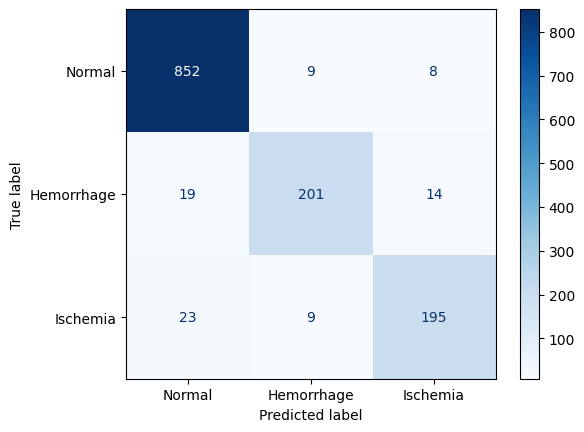

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("Confusion Matrix:")
confusion_matrix=confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['Normal', 'Hemorrhage', 'Ischemia']).plot(cmap=plt.cm.Blues)